<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Year_Season.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convert Year/Season → numeric year

Use logistic regression to test whether success probability changes over time

(Optional) Report a point-biserial correlation as a descriptive check

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions4.csv")

df.head()



,Yr/Seas,Host,Nationalities,Leader(s),Route(s),Result,Smtrs,Dead,ExpedID,Year,...,hired_count,hired_DR,mbr_DR,mbr_hired_ratio,total_DR,clean_routes,route_codes,result_clean,result_code,success_rate
0,1990 Spr,China,W Germany/Iran,Mischa Saleki,W Ridge from N,Route Difficulty,NaN,NaN,EVER-901-01,1990,...,0,0.0,0.0,0.00,0.0,w ridge from n,6,route difficulty,3,0
1,1990 Spr,China,"USA, Austria, Canada, Spain",Todd Burleson,W Ridge from N,"Illness, AMS",NaN,NaN,EVER-901-02,1990,...,4,0.0,0.0,0.31,0.0,w ridge from n,6,"illness, ams",4,0
2,1990 Spr,China,"USA, China, USSR","Jim Whittaker, Vladimir Shataev, Lobsang Dawa",N Col-NE Ridge,Success,20.0,NaN,EVER-901-03,1990,...,0,0.0,0.0,0.00,0.0,n col-ne ridge,2,success,1,1
3,1990 Spr,Nepal,Nepal,Chetra Bahadur Gurung,S Col-SE Ridge,Success,4.0,NaN,EVER-901-04,1990,...,2,0.0,0.0,0.08,0.0,s col-se ridge,1,success,1,1
4,1990 Spr,Nepal,Switzerland,Beda Fuster,Lho La-W Ridge (to 7450m) / S Col-SE Ridge (to...,"Illness, AMS",NaN,NaN,EVER-901-05,1990,...,0,0.0,0.0,0.00,0.0,lho la-w ridge,6,"illness, ams",4,0


In [ ]:
print(df.columns)
print(df.shape)


Index(['Yr/Seas', 'Host', 'Nationalities', 'Leader(s)', 'Route(s)', 'Result',
       'Smtrs', 'Dead', 'ExpedID', 'Year', 'expedition_code', 'group_size',
       'total_members', 'death_mbrs', 'hired_deaths', 'hired_count',
       'hired_DR', 'mbr_DR', 'mbr_hired_ratio', 'total_DR', 'clean_routes',
       'route_codes', 'result_clean', 'result_code', 'success_rate'],
      dtype='object')
(2192, 25)


In [ ]:
# keep only the columns we need and drop missing values
df = df[["Yr/Seas", "success_rate"]].dropna().copy()

# extract the numeric year from "Yr/Seas" (e.g. "2019 Spring" → 2019)
df["Year"] = (
    df["Yr/Seas"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

# ensure success_rate is numeric and binary (0 or 1 only)
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")
df = df[df["success_rate"].isin([0, 1])]

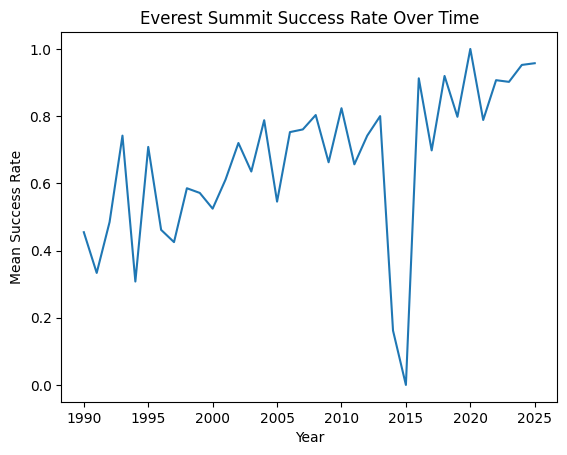

In [ ]:
import matplotlib.pyplot as plt

yearly_success = df.groupby("Year")["success_rate"].mean()

plt.figure()
plt.plot(yearly_success.index, yearly_success.values)
plt.xlabel("Year")
plt.ylabel("Mean Success Rate")
plt.title("Everest Summit Success Rate Over Time")
plt.show()
